# Projeto Computacional de Mecânica Clássica

In [ ]:
from __future__ import annotations
from typing import Iterable
import matplotlib.pyplot as plt
import math

In [172]:
def hello() -> None:
    print("Hello, world!")
    return

hello()

Hello, world!


## Calculo de Vetores

In [173]:
class Vec3:
    x: float
    y: float
    z: float

    def __init__(self, x: float, y: float, z: float) -> None:
        self.x = x
        self.y = y
        self.z = z
    def __repr__(self) -> str:
        return f"Vec3({self.x}, {self.y}, {self.z})"

    def __add__(self, other: Vec3 | float) -> Vec3:
        if isinstance(other, Vec3):
            return Vec3(self.x + other.x, self.y + other.y, self.z + other.z)
        return Vec3(self.x + other, self.y + other, self.z + other)
    def __radd__(self, other: float) -> Vec3:
        return self + other
    def __iadd__(self, other: Vec3 | float) -> Vec3:
        if isinstance(other, Vec3):
            self.x += other.x
            self.y += other.y
            self.z += other.z
        else:
            self.x += other
            self.y += other
            self.z += other
        return self
    def __sub__(self, other: Vec3 | float) -> Vec3:
        if isinstance(other, Vec3):
            return Vec3(self.x - other.x, self.y - other.y, self.z - other.z)
        return Vec3(self.x - other, self.y - other, self.z - other)
    def __rsub__(self, other: float) -> Vec3:
        return Vec3(other - self.x, other - self.y, other - self.z)
    def __isub__(self, other: Vec3 | float) -> Vec3:
        if isinstance(other, Vec3):
            self.x -= other.x
            self.y -= other.y
            self.z -= other.z
        else:
            self.x -= other
            self.y -= other
            self.z -= other
        return self
    def __neg__(self) -> Vec3:
        return Vec3(-self.x, -self.y, -self.z)
    def __mul__(self, other: Vec3 | float) -> float | Vec3:
        if isinstance(other, Vec3):
            # DOT PRODUCT
            return self.x * other.x + self.y * other.y + self.z * other.z
        return Vec3(self.x * other, self.y * other, self.z * other)
    def __rmul__(self, other: float) -> Vec3:
        return self * other
    def __imul__(self, other: float) -> Vec3:
        self.x *= other
        self.y *= other
        self.z *= other
        return self
    def __truediv__(self, other: float) -> Vec3:
        return Vec3(self.x / other, self.y / other, self.z / other)
    def __itruediv__(self, other: float) -> Vec3:
        self.x /= other
        self.y /= other
        self.z /= other
        return self
    def dot(self, other: Vec3) -> float:
        return self * other
    def __matmul__(self, other: Vec3) -> float:
        return self * other
    def cross(self, other: Vec3) -> Vec3:
        return Vec3(
            self.y * other.z - self.z * other.y,
            self.z * other.x - self.x * other.z,
            self.x * other.y - self.y * other.x,
        )
    def length(self) -> float:
        return math.sqrt(self * self)
    def normalize(self) -> Vec3:
        l = self.length()
        if l == 0:
            raise ValueError("Cannot normalize zero vector")
        return self / l

def sum_vec3(vectors: Iterable[Vec3]) -> Vec3:
    result = Vec3(0.0, 0.0, 0.0)
    for v in vectors:
        result += v
    return result

VEC_I = Vec3(1.0, 0.0, 0.0)
VEC_J = Vec3(0.0, 1.0, 0.0)
VEC_K = Vec3(0.0, 0.0, 1.0)

## Conceito de uma particula

In [174]:
class Particle:
    def __init__(self, mass: float, position: Vec3, velocity: Vec3) -> None:
        self.mass = mass
        self.position = position
        self.velocity = velocity
    def __repr__(self) -> str:
        return f"Particle(mass={self.mass}, position={self.position}, velocity={self.velocity})"
    
    def update_position(self, dt: float) -> None:
        self.position += self.velocity * dt
    def update_velocity(self, forces: list[Vec3], dt: float) -> None:
        total_force = sum_vec3(forces)
        acceleration = total_force / self.mass
        self.velocity += acceleration * dt

## Forças

### Gravidade 
#### $$\vec F_g = ma_g\cdot\hat k$$

In [175]:
def gravitational_force(particle: Particle, a:float) -> Vec3:
    magnitude = -particle.mass * a
    return VEC_K * magnitude

### Força de arrasto
#### $$\begin{matrix}\beta_\uparrow(z) = \beta_0 e^{-z/ H} && \gamma_\uparrow(z) = \gamma_0 e^{-z/ H}\\\beta_\downarrow(z) = r_\beta\beta_\uparrow(z) && \gamma_\downarrow(z) = r_\gamma\gamma_\uparrow(z)\end{matrix}$$
#### $$\vec F_d = \begin{cases} -\beta_\uparrow(z)\vec v - \gamma_\uparrow(z)|v|\vec v, & v_z > 0 & \text{(subida)}\\-\beta_\downarrow(z)\vec v + \gamma_\downarrow(z)|v|\vec v, & v_z < 0 & \text{(descida)} \end{cases}$$

In [176]:
def drag_beta_up(particle: Particle, beta_o: float, h: float) -> float:
    return beta_o * math.exp(-particle.position.z / h)
def drag_gamma_up(particle: Particle, gamma_o: float, h: float) -> float:
    return gamma_o * math.exp(-particle.position.z / h)
def drag_force(particle: Particle, beta_o: float, gamma_o: float, r_beta: float, r_gamma: float, h:float) -> Vec3:
    speed = particle.velocity.length()
    if particle.velocity.z > 0:
        beta = drag_beta_up(particle, beta_o, h)
        gamma = drag_gamma_up(particle, gamma_o, h)
        return particle.velocity * (-beta - gamma * speed)
    else:
        beta = r_beta * drag_beta_up(particle, beta_o, h)
        gamma = r_gamma * drag_gamma_up(particle, gamma_o, h)
        return particle.velocity * (-beta + gamma * speed)

## Simulação

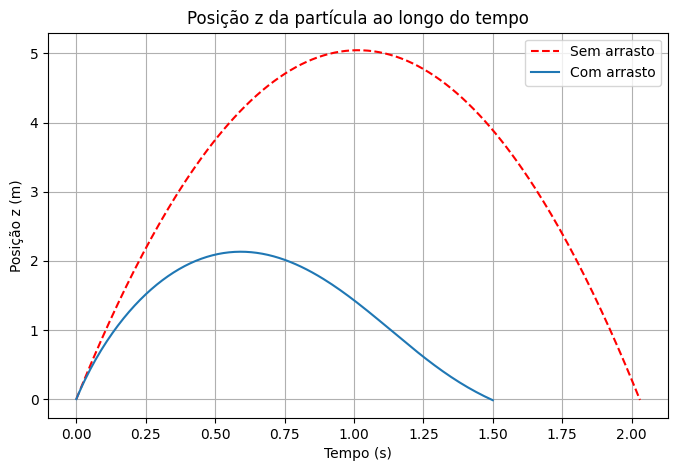

In [ ]:
## Parâmetros de simulação
TIME_STEP = 0.01                    # [s]
## Força Gravitacional
GRAVITATIONAL_ACCELERATION = 9.81   # [m/s^2]
## Força de arrasto
BETA_O = 4.0                        #
GAMMA_O = 0.05                      #
R_BETA = 2.0                        #
R_GAMMA = 1.0                       #
H = 1.0                             # [m]


def simulate_until_ground(with_drag=True):
    particle = Particle(mass=1.0, position=Vec3(0.0, 0.0, 0.0), velocity=Vec3(0.0, 0.0, 10.0))
    z_positions = [particle.position.z]
    times = [0.0]
    t = 0.0
    while particle.position.z >= 0:
        if with_drag:
            forces = [
                gravitational_force(particle, a=GRAVITATIONAL_ACCELERATION),
                drag_force(particle, beta_o=BETA_O, gamma_o=GAMMA_O, r_beta=R_BETA, r_gamma=R_GAMMA, h=H)
            ]
        else:
            forces = [
                gravitational_force(particle, a=GRAVITATIONAL_ACCELERATION)
            ]
        particle.update_velocity(forces, TIME_STEP)
        particle.update_position(TIME_STEP)
        t += TIME_STEP
        z_positions.append(particle.position.z)
        times.append(t)
        if len(times) > 1000000:  # safety break for infinite loop
            break
    return times, z_positions

times_drag, z_drag = simulate_until_ground(with_drag=True)
times_no_drag, z_no_drag = simulate_until_ground(with_drag=False)

plt.figure(figsize=(8,5))
plt.plot(times_no_drag, z_no_drag, 'r--', label='Sem arrasto')
plt.plot(times_drag, z_drag, label='Com arrasto')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição z (m)')
plt.title('Posição z da partícula ao longo do tempo')
plt.legend()
plt.grid(True)
plt.show()